
# Predicting Airbnb Listing Success (Albany, NY) — Week 7 

**Dataset**: Inside Airbnb — Albany, NY (Aug 2025) → `listings.csv`

This updated notebook fixes:
- Robust `DATA_PATH` resolution (relative path first; falls back to `/mnt/data/listings.csv` if present).
- Geospatial EDA sampling (no oversampling vs. population).
- Pipelines now **impute** missing values before scaling/encoding, so models won't error on NaNs.
- `bathrooms_text` parsed into numeric `bathrooms_parsed`; raw text removed from numeric features.
- Version-safe `OneHotEncoder` (`sparse_output` vs `sparse`).


In [1]:

# === Imports & Setup ===
import os, sys, math, warnings, json, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# ---- Robust DATA_PATH ----
candidate_paths = [
    "listings.csv",               # same folder as notebook (Windows-safe)
    "./listings.csv",
    "../listings.csv",
    "/mnt/data/listings.csv"      # fallback to uploaded file path in this environment
]
DATA_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Could not find listings.csv. Place it beside the notebook or update DATA_PATH manually.")

print("Using DATA_PATH =", DATA_PATH)
pd.set_option('display.max_columns', 120)


Using DATA_PATH = listings.csv


## Part 1 — Data Loading & Cleaning

In [2]:

# Load data
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Shape:", df.shape)
print("\nData Types (head):")
print(df.dtypes.head(40))

print("\nMissing values (top 40 columns):")
print(df.isna().sum().sort_values(ascending=False).head(40))

df.head(3)


Shape: (459, 79)

Data Types (head):
id                                int64
listing_url                      object
scrape_id                         int64
last_scraped                     object
source                           object
name                             object
description                      object
neighborhood_overview            object
picture_url                      object
host_id                           int64
host_url                         object
host_name                        object
host_since                       object
host_location                    object
host_about                       object
host_response_time               object
host_response_rate               object
host_acceptance_rate             object
host_is_superhost                object
host_thumbnail_url               object
host_picture_url                 object
host_neighbourhood               object
host_listings_count               int64
host_total_listings_count         int64
hos

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,Kenneth,2013-01-07,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,50%,f,https://a0.muscache.com/im/users/4621559/profi...,https://a0.muscache.com/im/users/4621559/profi...,NaN,1,5,"['email', 'phone']",t,t,NaN,THIRD WARD,NaN,42.65789,-73.75370,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""TV with standard cable"", ""Carbon monoxide al...",$70.00,28,1125,28,28,1125,1125,28.0,1125.0,NaN,t,0,0,0,126,2025-08-04,9,0,0,0,0,0,0.0,2014-07-01,2022-08-17,3.56,3.44,3.56,4.22,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,Terra,2014-08-07,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Center Square & Hudson/Park,4,6,"['email', 'phone']",t,t,Neighborhood highlights,SIXTH WARD,NaN,42.65222,-73.76724,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Dishwasher"", ""Coffee maker"", ""HDTV with stan...",$104.00,2,1125,2,3,1125,1125,2.8,1125.0,NaN,t,2,32,62,337,2025-08-04,310,5,0,122,15,30,3120.0,2014-08-15,2025-06-30,4.74,4.88,4.87,4.85,4.81,4.81,4.77,NaN,f,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,https://www.airbnb.com/users/show/29288920,Gregg,2015-03-13,"Albany, NY",I am an Albany native .I have lived in Ireland...,within an hour,100%,99%,f,https://a0.muscache.com/im/users/29288920/prof...,https://a0.muscache.com/im/users/29288920/prof...,NaN,2,2,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,SECOND WARD,NaN,42.64615,-73.75966,Entire rental unit,Entire home/apt,2,1.0,1 bath,0.0,1.0,"[""Coffee maker"", ""TV"", ""Oven"", ""Bed linens"", ""...",$75.00,2,45,1,2,1125,1125,1.3,1125.0,NaN,t,9,11,39,39,2025-08-04,371,11,0,39,38,66,4

In [3]:

# Money-like columns
def money_to_float(s):
    if pd.isna(s):
        return np.nan
    if isinstance(s, (int, float)):
        return float(s)
    ss = str(s).strip().replace('$','').replace(',','')
    try:
        return float(ss) if ss != "" else np.nan
    except:
        return np.nan

for col in ['price','weekly_price','monthly_price','security_deposit','cleaning_fee','extra_people']:
    if col in df.columns:
        df[col] = df[col].apply(money_to_float)

# Dates
for dcol in ['host_since','first_review','last_review','calendar_last_scraped','last_scraped']:
    if dcol in df.columns:
        df[dcol] = pd.to_datetime(df[dcol], errors='coerce')

# Bathrooms parsing
def parse_bathrooms_text(txt):
    if pd.isna(txt):
        return np.nan
    s = str(txt).lower().strip()
    has_half = ('half' in s) or ('0.5' in s)
    m = re.search(r'(\d+(?:\.\d+)?)', s)
    if m:
        val = float(m.group(1))
        if has_half and abs(val - round(val)) < 1e-9:
            val += 0.5
        return val
    return 0.5 if has_half else np.nan

df['bathrooms'] = pd.to_numeric(df.get('bathrooms'), errors='coerce') if 'bathrooms' in df.columns else np.nan
df['bathrooms_from_text'] = df['bathrooms_text'].apply(parse_bathrooms_text) if 'bathrooms_text' in df.columns else np.nan
df['bathrooms_parsed'] = df['bathrooms'].fillna(df['bathrooms_from_text'])

# Skewness snapshot
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skewness = df[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)
print("\nSkewness (top 15):\n", skewness.head(15))
print("✅ Cleaning done")



Skewness (top 15):
 minimum_minimum_nights       14.491160
minimum_nights_avg_ntm       14.071503
maximum_minimum_nights       14.050565
minimum_nights               13.284273
host_total_listings_count     7.958853
host_listings_count           6.877950
price                         5.189938
bathrooms                     4.485494
bathrooms_parsed              4.136835
bathrooms_from_text           4.136835
number_of_reviews             3.981278
number_of_reviews_ly          2.634020
number_of_reviews_ltm         2.560434
estimated_revenue_l365d       2.180754
accommodates                  2.046847
dtype: float64
✅ Cleaning done


## Part 2 — EDA (Exploratory Data Analysis)

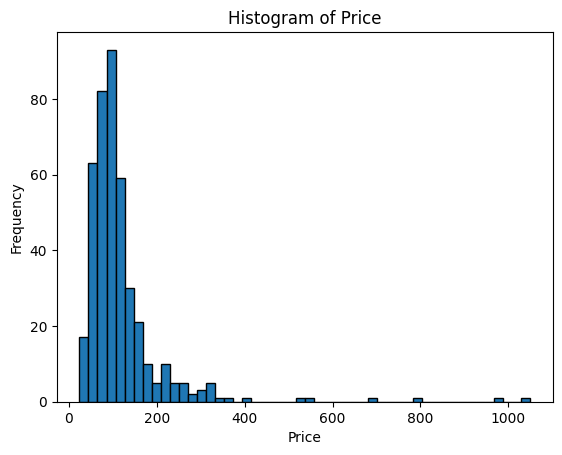

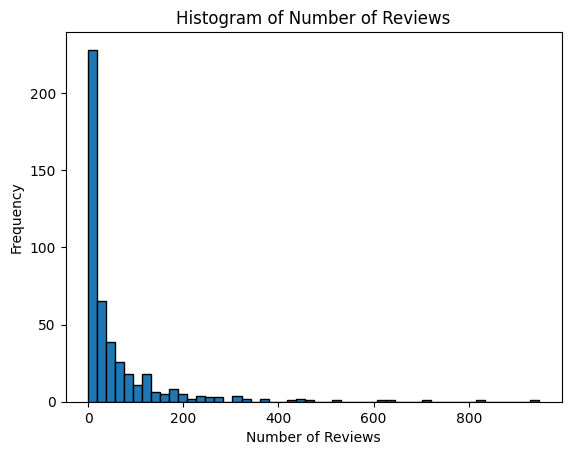

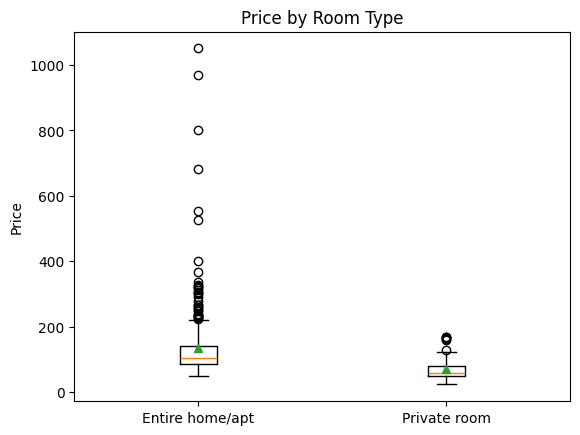

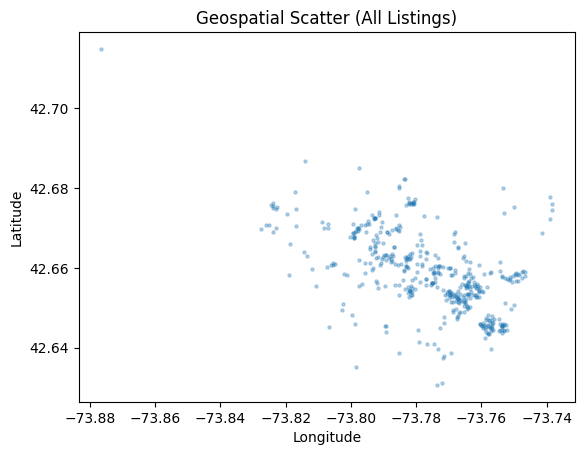

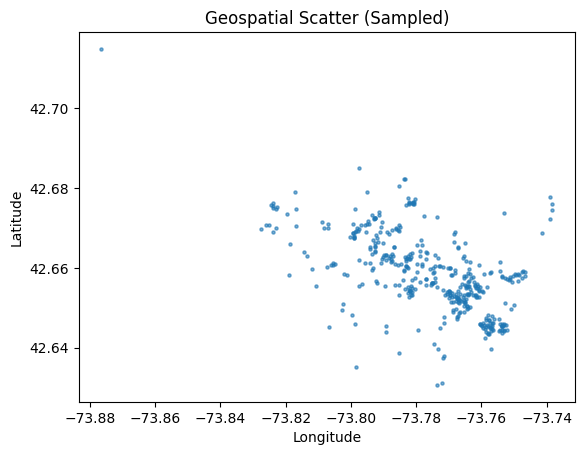

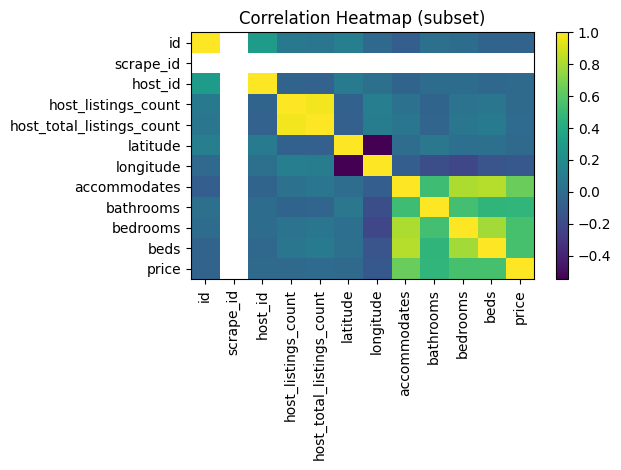

In [4]:

# 1) Histogram of price
plt.figure()
df['price'].dropna().plot(kind='hist', bins=50, edgecolor='black')
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 2) Histogram of number_of_reviews
if 'number_of_reviews' in df.columns:
    plt.figure()
    df['number_of_reviews'].dropna().plot(kind='hist', bins=50, edgecolor='black')
    plt.title('Histogram of Number of Reviews')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Frequency')
    plt.show()

# 3) Box plot of price by room_type
if 'room_type' in df.columns:
    plt.figure()
    grouped = [g['price'].dropna().values for _, g in df.groupby('room_type')]
    labels = list(df.groupby('room_type').groups.keys())
    plt.boxplot(grouped, labels=labels, vert=True, showmeans=True)
    plt.title('Price by Room Type')
    plt.ylabel('Price')
    plt.xticks(rotation=0)
    plt.show()

# 4) Geospatial scatter(s)
if all(c in df.columns for c in ['latitude','longitude']):
    plt.figure()
    plt.scatter(df['longitude'], df['latitude'], s=5, alpha=0.3)
    plt.title('Geospatial Scatter (All Listings)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

    if all(c in df.columns for c in ['price','latitude','longitude']):
        valid = df.dropna(subset=['price','latitude','longitude'])
        n = min(5000, len(valid))
        if n > 0:
            sample = valid.sample(n=n, random_state=42)
            plt.figure()
            plt.scatter(sample['longitude'], sample['latitude'], s=5, alpha=0.6)
            plt.title('Geospatial Scatter (Sampled)')
            plt.xlabel('Longitude')
            plt.ylabel('Latitude')
            plt.show()

# 5) Correlation heatmap (subset)
num_subset = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
num_subset = num_subset.iloc[:, :min(12, num_subset.shape[1])]
if num_subset.shape[1] >= 2:
    corr = num_subset.corr(numeric_only=True)
    plt.figure()
    plt.imshow(corr, aspect='auto', interpolation='nearest')
    plt.colorbar()
    plt.title('Correlation Heatmap (subset)')
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
    plt.yticks(range(corr.shape[0]), corr.index)
    plt.tight_layout()
    plt.show()


## Part 3 — Feature Engineering

In [5]:

# Engineered features: amenities_count, host_tenure_days, distance_to_center_km, description lengths, days_since_last_review
ALBANY_CENTER = (42.6526, -73.7562)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# amenities_count
if 'amenities' in df.columns:
    df['amenities_count'] = df['amenities'].fillna('').apply(lambda x: len(str(x).strip('{}').split(',')) if isinstance(x, str) else 0)
else:
    df['amenities_count'] = np.nan

# description lengths
for text_col in ['description','name','neighborhood_overview']:
    if text_col in df.columns:
        df[f'{text_col}_length_chars'] = df[text_col].astype(str).apply(lambda s: len(s) if s.lower()!='nan' else 0)
        df[f'{text_col}_length_words'] = df[text_col].astype(str).apply(lambda s: len([w for w in s.split() if w]) if s.lower()!='nan' else 0)

# host_tenure_days
if 'last_scraped' in df.columns and df['last_scraped'].notna().any():
    ref_date = df['last_scraped'].max()
else:
    ref_date = pd.Timestamp('2025-10-17')

if 'host_since' in df.columns:
    df['host_tenure_days'] = (ref_date - df['host_since']).dt.days
else:
    df['host_tenure_days'] = np.nan

# distance_to_center_km
if all(c in df.columns for c in ['latitude','longitude']):
    df['distance_to_center_km'] = haversine(df['latitude'], df['longitude'], ALBANY_CENTER[0], ALBANY_CENTER[1])
else:
    df['distance_to_center_km'] = np.nan

# days_since_last_review
if 'last_review' in df.columns:
    df['days_since_last_review'] = (ref_date - df['last_review']).dt.days
else:
    df['days_since_last_review'] = np.nan

engineered_cols = [c for c in df.columns if c.endswith('_count') or c.endswith('_days') or c.endswith('_km') or 'length_' in c]
df[engineered_cols].head(5)


,host_listings_count,host_total_listings_count,calculated_host_listings_count,amenities_count,description_length_chars,description_length_words,name_length_chars,name_length_words,neighborhood_overview_length_chars,neighborhood_overview_length_words,host_tenure_days,distance_to_center_km
0,1,5,1,8,166,27,26,4,0,0,4592,0.622737
1,4,6,4,37,555,85,50,8,1000,153,4015,0.903855
2,2,2,2,33,435,69,42,8,421,73,3797,0.771014
3,4,6,4,32,550,81,49,10,1000,153,4015,0.903855
4,1,1,1,33,375,61,46,10,255,39,4046,0.797202


In [6]:

# Targets
target_reg = 'price'
target_clf = 'popular'

# Binary popularity
if 'number_of_reviews' in df.columns:
    median_reviews = df['number_of_reviews'].median()
    df[target_clf] = (df['number_of_reviews'] > median_reviews).astype(int)
else:
    df[target_clf] = 0

# Feature lists
num_features = [
    'accommodates','bedrooms','beds','bathrooms_parsed',
    'minimum_nights','maximum_nights',
    'availability_30','availability_60','availability_90','availability_365',
    'number_of_reviews','reviews_per_month','review_scores_rating','review_scores_accuracy',
    'review_scores_cleanliness','review_scores_checkin','review_scores_communication',
    'review_scores_location','review_scores_value',
    'calculated_host_listings_count','calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms',
    'host_tenure_days','amenities_count','distance_to_center_km','days_since_last_review',
    'description_length_chars','description_length_words',
]
num_features = [c for c in num_features if c in df.columns]

cat_features = [f for f in ['room_type','neighbourhood_cleansed','host_is_superhost','instant_bookable','property_type'] if f in df.columns]

print("✅ Numeric features:", len(num_features))
print("✅ Categorical features:", len(cat_features))

# Splits
df_reg = df.dropna(subset=[target_reg]).copy()
reg_train, reg_test = train_test_split(df_reg, test_size=0.2, random_state=42)

clf_cols = list(set(cat_features + num_features + [target_clf]))
clf_train, clf_test = train_test_split(df.dropna(subset=[c for c in clf_cols if c in df.columns]), test_size=0.2, random_state=42)


✅ Numeric features: 29
✅ Categorical features: 5


In [7]:

# Version-safe OHE + imputers
from sklearn import __version__ as skl_ver
try:
    from packaging import version
    use_sparse_output = version.parse(skl_ver) >= version.parse("1.4")
except Exception:
    use_sparse_output = False

if use_sparse_output:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ])
else:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=True))
    ])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='drop'
)
print(f"✅ Preprocess ready (sparse_output={use_sparse_output})")


✅ Preprocess ready (sparse_output=True)


## Part 4 — Regression Modeling (Predict Price)

In [8]:

X_train = reg_train[cat_features + num_features]
y_train = reg_train['price'].values
X_test  = reg_test[cat_features + num_features]
y_test  = reg_test['price'].values

# 1) Linear Regression
linreg = Pipeline(steps=[('prep', preprocess), ('model', LinearRegression())])
linreg.fit(X_train, y_train)
pred_lr = linreg.predict(X_test)

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = reg_metrics(y_test, pred_lr)
print(f"Linear Regression — MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}, R²: {lr_r2:.3f}")

# 2) Random Forest
rf = Pipeline(steps=[('prep', preprocess), ('model', RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1))])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rf_mae, rf_rmse, rf_r2 = reg_metrics(y_test, pred_rf)
print(f"Random Forest — MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R²: {rf_r2:.3f}")

# 2b) Tuned RF (on subset for speed)
param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10]
}
grid = GridSearchCV(
    estimator=Pipeline(steps=[('prep', preprocess), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0
)

subset_n = min(5000, len(X_train))
grid.fit(X_train.sample(subset_n, random_state=42), y_train[:subset_n])
best_rf = grid.best_estimator_
pred_brf = best_rf.predict(X_test)
brf_mae, brf_rmse, brf_r2 = reg_metrics(y_test, pred_brf)
print(f"Tuned RF — MAE: {brf_mae:.2f}, RMSE: {brf_rmse:.2f}, R²: {brf_r2:.3f} | Best Params: {grid.best_params_}")

# 3) Gradient Boosting
gbr = Pipeline(steps=[('prep', preprocess), ('model', GradientBoostingRegressor(random_state=42))])
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)
gbr_mae, gbr_rmse, gbr_r2 = reg_metrics(y_test, pred_gbr)
print(f"Gradient Boosting — MAE: {gbr_mae:.2f}, RMSE: {gbr_rmse:.2f}, R²: {gbr_r2:.3f}")

results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Tuned Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, rf_mae, brf_mae, gbr_mae],
    'RMSE': [lr_rmse, rf_rmse, brf_rmse, gbr_rmse],
    'R2': [lr_r2, rf_r2, brf_r2, gbr_r2]
}).sort_values('MAE')
results_reg


Linear Regression — MAE: 46.95, RMSE: 65.00, R²: 0.572
Random Forest — MAE: 34.46, RMSE: 61.12, R²: 0.621
Tuned RF — MAE: 54.82, RMSE: 99.38, R²: -0.001 | Best Params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Gradient Boosting — MAE: 38.93, RMSE: 73.39, R²: 0.454


,Model,MAE,RMSE,R2
1,Random Forest,34.462738,61.122689,0.621372
3,Gradient Boosting,38.929158,73.389484,0.454147
0,Linear Regression,46.950893,64.997661,0.571842
2,Tuned Random Forest,54.824648,99.379259,-0.000921


## Part 5 — Classification Modeling (Predict Popularity)

Logistic Regression — Precision: 0.925, Recall: 0.925, F1: 0.925, ROC AUC: 0.975
Random Forest      — Precision: 1.000, Recall: 1.000, F1: 1.000, ROC AUC: 1.000

Confusion Matrix (Logistic Regression):
 [[29  3]
 [ 3 37]]

Confusion Matrix (Random Forest):
 [[32  0]
 [ 0 40]]


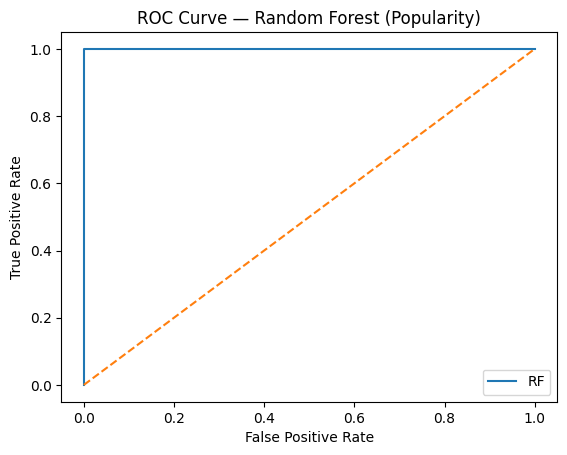

In [9]:

Xc_train = clf_train[cat_features + num_features]
yc_train = clf_train['popular'].values
Xc_test  = clf_test[cat_features + num_features]
yc_test  = clf_test['popular'].values

# Logistic Regression
log_clf = Pipeline(steps=[('prep', preprocess), ('model', LogisticRegression(max_iter=1000))])
log_clf.fit(Xc_train, yc_train)
pred_log = log_clf.predict(Xc_test)
proba_log = log_clf.predict_proba(Xc_test)[:,1]

# Random Forest
rf_clf = Pipeline(steps=[('prep', preprocess), ('model', RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1))])
rf_clf.fit(Xc_train, yc_train)
pred_rf = rf_clf.predict(Xc_test)
proba_rf = rf_clf.predict_proba(Xc_test)[:,1]

def clf_report(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    return cm, p, r, f1, auc

cm_log, p_log, r_log, f1_log, auc_log = clf_report(yc_test, pred_log, proba_log)
cm_rf,  p_rf,  r_rf,  f1_rf,  auc_rf  = clf_report(yc_test, pred_rf,  proba_rf )

print(f"Logistic Regression — Precision: {p_log:.3f}, Recall: {r_log:.3f}, F1: {f1_log:.3f}, ROC AUC: {auc_log:.3f}")
print(f"Random Forest      — Precision: {p_rf:.3f}, Recall: {r_rf:.3f}, F1: {f1_rf:.3f}, ROC AUC: {auc_rf:.3f}")

print("\nConfusion Matrix (Logistic Regression):\n", cm_log)
print("\nConfusion Matrix (Random Forest):\n", cm_rf)

# ROC curve (RF)
fpr, tpr, thresh = roc_curve(yc_test, proba_rf)
plt.figure()
plt.plot(fpr, tpr, label='RF')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest (Popularity)')
plt.legend()
plt.show()



**Business meaning of errors (classification):**
- **False Positive (predict popular but it's not)** → Wasted promo budget on low-demand listings.
- **False Negative (predict not popular but it is)** → Missed opportunity to boost a high-potential listing.


## Part 6 — Neural Network Experiment (MLP Regressor)

In [10]:

mlp = Pipeline(steps=[
    ('prep', preprocess),
    ('model', MLPRegressor(hidden_layer_sizes=(128,64), activation='relu', solver='adam',
                           random_state=42, max_iter=200, early_stopping=True))
])
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

mlp_mae = mean_absolute_error(y_test, pred_mlp)
mlp_rmse = mean_squared_error(y_test, pred_mlp, squared=False)
mlp_r2 = r2_score(y_test, pred_mlp)
print(f"MLP Regressor — MAE: {mlp_mae:.2f}, RMSE: {mlp_rmse:.2f}, R²: {mlp_r2:.3f}")

try:
    results_reg_mlp = results_reg.copy()
    results_reg_mlp.loc[len(results_reg_mlp)] = ['MLP (Neural Net)', mlp_mae, mlp_rmse, mlp_r2]
    results_reg_mlp.sort_values('MAE')
except NameError:
    print("Note: results_reg not found; skipping combined comparison table.")


MLP Regressor — MAE: 49.28, RMSE: 100.67, R²: -0.027



## Deliverables Checklist
- ✅ Cleaning (money, dates, bathrooms parsing), missing values & skewness
- ✅ EDA: price & reviews histograms, price-by-room_type boxplot, geospatial scatters, correlation heatmap
- ✅ Feature engineering: amenities_count, host_tenure_days, distance_to_center_km, description lengths, days_since_last_review
- ✅ Regression: Linear, Random Forest (+ tuning), Gradient Boosting
- ✅ Classification: Logistic & Random Forest with confusion matrices and ROC/AUC
- ✅ Neural Network: MLP (comparison vs classical models)


